In [1]:
# Tools 
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper
from langchain_community.tools.arxiv.tool import ArxivQueryRun
from langchain_community.tools.wikipedia.tool import WikipediaQueryRun

In [2]:
arxiv_api_wrapper = ArxivAPIWrapper(top_k_results=3, doc_content_chars_max=1000)
arxiv = ArxivQueryRun(api_wrapper=arxiv_api_wrapper)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension. The resulting architecture is simply a series of feed-forward layers applied over the patch and feature dimensions in an alternating fashion. In experiments on ImageNet, this architecture performs surprisingly well: a ViT/DeiT-base-sized model obtains 74.9\\% top-1 accuracy, compared to 77.9\\% and 79.9\\% for ViT and DeiT respectively. These results indicate that aspects

In [4]:
wikipedia_api_wrapper = WikipediaAPIWrapper(top_k_results=3, doc_content_chars_max=2000)
wikipedia = WikipediaQueryRun(api_wrapper=wikipedia_api_wrapper)
print(wikipedia.name)

wikipedia


In [5]:
import os 
from dotenv import load_dotenv

load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

In [6]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

C:\Users\user\AppData\Local\Temp\ipykernel_17344\735679136.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [7]:
tavily.invoke('who is the current interior minister of pakistan state?')

[{'title': 'Mohsin Naqvi - Wikipedia',
  'url': 'https://en.wikipedia.org/wiki/Mohsin_Naqvi',
  'content': '### Interior Minister of Pakistan (2024–present)\n\nIn March 2024, reports emerged that Mohsin Naqvi was being considered for the position of Interior Minister in Shehbaz Sharif\'s federal cabinet. The nomination was initially met with denials from the PML-N and PPP. A senior PML-N leader stated Naqvi was not their party\'s candidate, while a PPP leader referred to him as "Rawalpindi\'s man "General Headquarters (Pakistan Army)")," a term understood to reference the Pakistani military establishment. [...] Syed Mohsin Raza Naqvi (born 28 October 1978) is a Pakistani politician and media mogul who has served as the federal Minister of Interior "Ministry of Interior (Pakistan)") and Narcotics Control "Ministry of Narcotics Control (Pakistan)") since March 2024, and the chairman "Chair (officer)") of the Pakistan Cricket Board since February 2024. He is also currently serving as the 

In [8]:
# Combining all the tools here
tools = [arxiv, wikipedia, tavily]

In [9]:
# Now initializing the LLM Model
from langchain_groq import ChatGroq

llm = ChatGroq(model_name="llama-3.3-70b-versatile")

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
# Binding tools with LLM
llm_with_tools = llm.bind_tools(tools=tools)

In [11]:
llm_with_tools.invoke("What is the recent released model of Claude?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'sra59s2nt', 'function': {'arguments': '{"query":"Claude recent model"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 556, 'total_tokens': 577, 'completion_time': 0.068266534, 'completion_tokens_details': None, 'prompt_time': 0.08451479, 'prompt_tokens_details': None, 'queue_time': 0.204953427, 'total_time': 0.152781324}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_43d97c5965', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eca74-c646-73d2-b8cb-dc9881cc223d-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'Claude recent model'}, 'id': 'sra59s2nt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 556, 'output_tokens': 21, 'total_tokens': 577})

In [12]:
llm_with_tools.invoke("What is the latest research paper on agentic ai?")

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'fjavytjyh', 'function': {'arguments': '{"query":"agentic ai latest research paper"}', 'name': 'arxiv'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 558, 'total_tokens': 578, 'completion_time': 0.067750332, 'completion_tokens_details': None, 'prompt_time': 0.058621641, 'prompt_tokens_details': None, 'queue_time': 0.276999979, 'total_time': 0.126371973}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_d42c28f9ce', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eca74-c88c-77c3-a2fe-4316f6159b0a-0', tool_calls=[{'name': 'arxiv', 'args': {'query': 'agentic ai latest research paper'}, 'id': 'fjavytjyh', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 558, 'output_tokens': 20, 'total_tokens': 578})

In [13]:
from typing_extensions import TypedDict
from typing import Annotated
from langgraph.graph.message import add_messages
from langchain_core.messages import AnyMessage

In [14]:
class State(TypedDict):
  messages: Annotated[list[AnyMessage], add_messages]

In [15]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import display, Image

In [16]:
def tool_calling_llm(state: State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

In [20]:
builder = StateGraph(State)

# Adding nodes
builder.add_node('tool_calling_llm', tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Adding edges
builder.add_edge(START, 'tool_calling_llm')
builder.add_conditional_edges(
  "tool_calling_llm", tools_condition
)
# builder.add_edge("tools", "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)

graph = builder.compile()

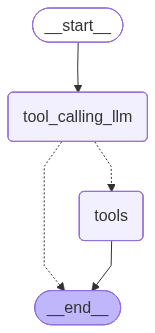

In [21]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
response = graph.invoke({"messages": "hi my name is ahmad. please tell me that which role is better in terms of demand and career growth and a fresher can get job in that role without any experience agentic ai engineer or sales development representative. tell me in one sentence and also tell which one should I opt if i have production level projects in both fields?"})
for res in response["messages"]:
  res.pretty_print()

================================ Human Message =================================

hi my name is ahmad. please tell me that which role is better in terms of demand and career growth and a fresher can get job in that role without any experience agentic ai engineer or sales development representative. tell me in one sentence and also tell which one should I opt if i have production level projects in both fields?
================================== Ai Message ==================================

As a fresher, Agentic AI Engineer is likely a better role in terms of demand and career growth, and having production-level projects in both fields, I would recommend opting for Agentic AI Engineer due to its higher potential for career advancement and industry relevance.
